In [62]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [63]:
opinions_df = pd.read_csv("D:/SEM VI/Project/Dataset/opinions.csv")
edges_df = pd.read_csv("D:/SEM VI/Project/Dataset/edges.csv")

In [64]:
G = nx.Graph()

for _, row in opinions_df.iterrows():
    G.add_node(row["node"], politics=row["politics"])

for _, row in edges_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        sign=row["sign"]
    )

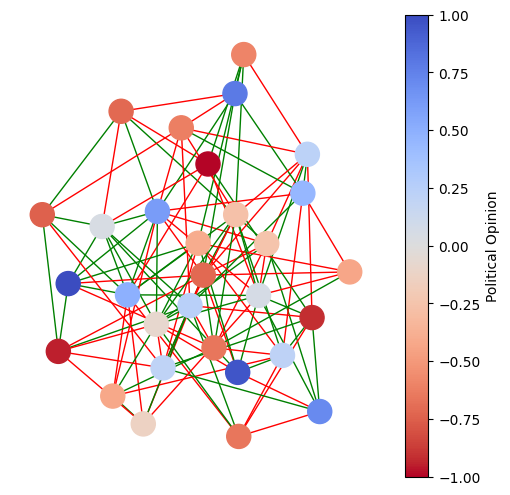

In [65]:
pos = nx.spring_layout(G, seed=42)

edge_colors = [
    "green" if G[u][v]["sign"] == 1 else "red"
    for u, v in G.edges
]

node_colors = [
    G.nodes[n]["politics"] for n in G.nodes
]

fig, ax = plt.subplots(figsize=(6, 6))

nx.draw(
    G,
    pos,
    edge_color=edge_colors,
    node_color=node_colors,
    cmap=plt.cm.coolwarm_r,
    node_size=300,
    with_labels=False,
    ax=ax
)

sm = mpl.cm.ScalarMappable(
    cmap=mpl.cm.coolwarm_r,
    norm=mpl.colors.Normalize(vmin=-1, vmax=1)
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Political Opinion")

plt.show()


In [66]:
def update_opinions_signed(G, alpha=0.2):
    new_values = {}

    for i in G.nodes:
        x_i = G.nodes[i]["politics"]
        influence = 0

        for j in G.neighbors(i):
            sign = G[i][j]["sign"]
            x_j = G.nodes[j]["politics"]
            influence += sign * (x_j - x_i)

        x_new = x_i + alpha * influence
        x_new = np.clip(x_new, -1, 1)
        new_values[i] = x_new

    for i in new_values:
        G.nodes[i]["politics"] = new_values[i]
    

In [67]:
T = 60
history = []

for _ in range(T):
    history.append([G.nodes[i]["politics"] for i in G.nodes])
    update_opinions_signed(G)

history = np.array(history)

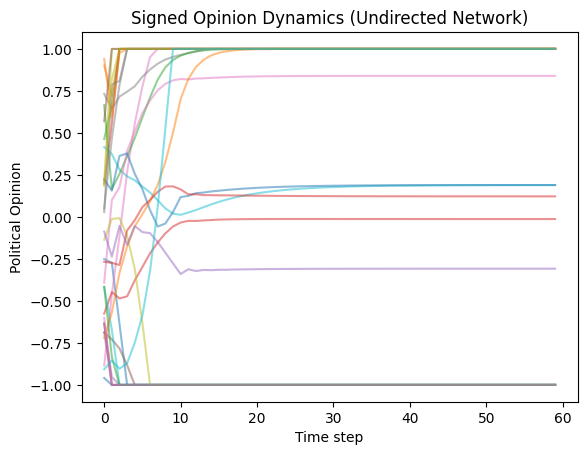

In [68]:
plt.plot(history, alpha=0.5)
plt.xlabel("Time step")
plt.ylabel("Political Opinion")
plt.title("Signed Opinion Dynamics (Undirected Network)")
plt.show()

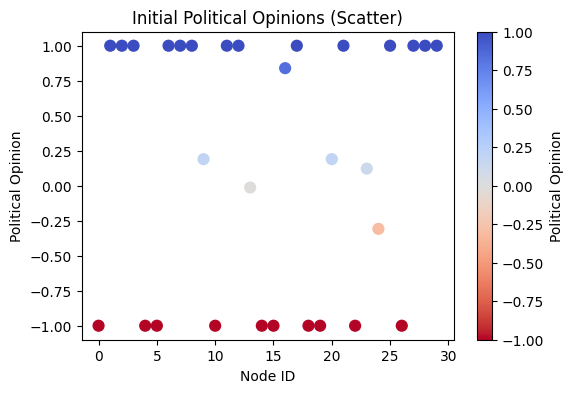

In [69]:
nodes = list(G.nodes)
opinions = [G.nodes[n]["politics"] for n in nodes]

plt.figure(figsize=(6, 4))
plt.scatter(
    nodes,
    opinions,
    c=opinions,
    cmap=plt.cm.coolwarm_r,
    s=60
)
plt.colorbar(label="Political Opinion")
plt.xlabel("Node ID")
plt.ylabel("Political Opinion")
plt.title("Initial Political Opinions (Scatter)")
plt.show()

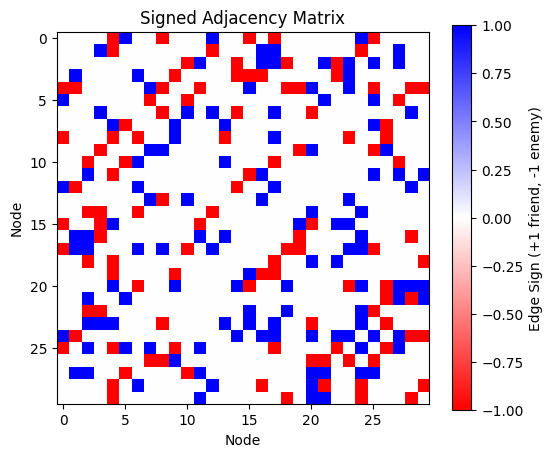

In [70]:
A = nx.to_numpy_array(G, weight="sign")

plt.figure(figsize=(6, 5))
plt.imshow(A, cmap="bwr_r", vmin=-1, vmax=1)
plt.colorbar(label="Edge Sign (+1 friend, -1 enemy)")
plt.xlabel("Node")
plt.ylabel("Node")
plt.title("Signed Adjacency Matrix")
plt.show()